# Free protein in solution

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib as mpl

In [3]:
data1 = pd.read_csv("closed_rep0.csv")
data2 = pd.read_csv("closed_rep1.csv")
data3 = pd.read_csv("closed_rep2.csv")
data4 = pd.read_csv("free_ensemble.csv")
data5 = pd.read_csv("free_ensemble_rep1.csv")
data6 = pd.read_csv("free_ensemble_rep2.csv")

# Unisci le 3 repliche closed
replica123 = pd.concat([data1, data2, data3], ignore_index=True)
replica123["dataset"] = "replica1-3"

# Unisci le 3 repliche free ensemble
free_ensemble_all = pd.concat([data4, data5, data6], ignore_index=True)
free_ensemble_all["dataset"] = "free_ensemble_rep0-2"

In [4]:
df_all = pd.concat([replica123, free_ensemble_all], ignore_index=True)

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

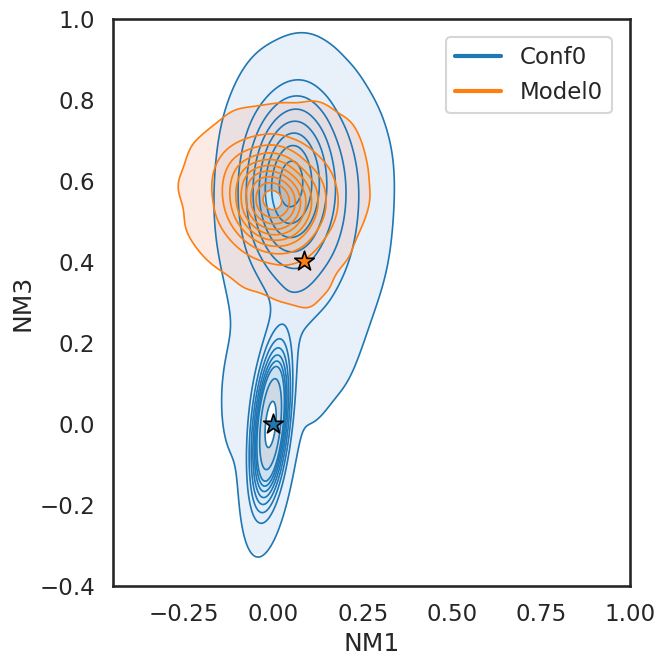

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="talk")


X_LIM = (-0.45, 1.0)
Y_LIM = (-0.40, 1.0)


name_map = {
    "replica1-3": "Conf0",
    "free_ensemble_rep0-2": "Model0",
}

colors = {
    "replica1-3": "#1f77b4",           # blu
    "free_ensemble_rep0-2": "#ff7f0e", # arancione
}


star_coords = {
    "replica1-3": (0.0, 0.0),            # (NM1, NM3)
    "free_ensemble_rep0-2": (0.086, 0.403),
}

levels = np.linspace(0.010, 0.95, 10)

BW = 2.
GRIDSIZE = 400
THRESH = 0.0
CUT = 4

fig, ax = plt.subplots(figsize=(7, 7))

order = ["replica1-3", "free_ensemble_rep0-2"]

for key in order:
    d = df_all[df_all["dataset"] == key]


    sns.kdeplot(
        data=d,
        x="NM1",
        y="NM3",
        fill=True,
        levels=levels,
        thresh=THRESH,
        bw_adjust=BW,
        gridsize=GRIDSIZE,
        color=colors[key],
        alpha=0.25,
        ax=ax
    )


    sns.kdeplot(
        data=d,
        x="NM1",
        y="NM3",
        fill=False,
        levels=levels,
        thresh=THRESH,
        bw_adjust=BW,
        gridsize=GRIDSIZE,
        cut=CUT,
        color=colors[key],
        linewidths=1.2,
        ax=ax
    )


for key in order:
    x, y = star_coords[key]
    ax.scatter(
        x, y,
        marker="*",
        color=colors[key],
        s=220,
        edgecolor="black",
        linewidth=1.2,
        zorder=10
    )


ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)

ax.set_xlabel("NM1")
ax.set_ylabel("NM3")


handles = [
    Line2D([0], [0], color=colors[k], lw=3, label=name_map[k])
    for k in order
]

ax.legend(
    handles=handles,
    loc="upper right",
    borderaxespad=0.8,
    frameon=True
)

plt.tight_layout()
fig.savefig(
    "NM_projection_free.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


# Free protein in solution clamp

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [8]:
data1 = np.load("dist_clamp_closed0.npy")
data2 = np.load("dist_clamp_closed1.npy")
data3 = np.load("dist_clamp_closed2.npy")
data4 = np.load("dist_clamp_free.npy")
data11 = np.load("dist_clamp_free_rep1.npy")
data12 = np.load("dist_clamp_free_rep2.npy")
data5 = np.load("dist_clamp_donor0.npy")
data6 = np.load("dist_clamp_donor1.npy")
data7 = np.load("dist_clamp_donor2.npy")
data8 = np.load("dist_clamp_full_rep0.npy")
data9 = np.load("dist_clamp_full_rep1.npy")
data10 = np.load("dist_clamp_full_rep2.npy")

replica123 = np.concatenate([data1, data2, data3])
replicao123 = np.concatenate([data4, data11, data12])
replicad123 = np.concatenate([data5, data6, data7])
replicaf123 = np.concatenate([data8, data9, data10])


df_rep = pd.DataFrame({"distance": replica123})
df_rep["dataset"] = "replica1-3"

df_free = pd.DataFrame({"distance": replicao123})
df_free["dataset"] = "data4"

df_repd = pd.DataFrame({"distance": replicad123})
df_repd["dataset"] = "replicad1-3"

df_repf = pd.DataFrame({"distance": replicaf123})
df_repf["dataset"] = "replicaf1-3"

df_all = pd.concat([df_rep, df_free, df_repd,df_repf], ignore_index=True)

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

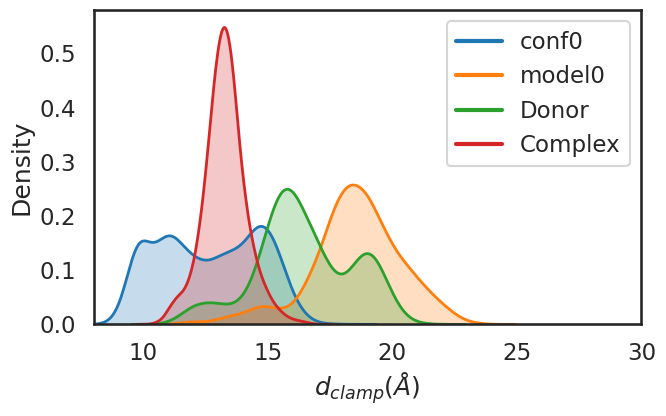

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D



sns.set_theme(style="white", context="talk")

name_map = {
    "replica1-3":   "conf0",
    "data4":        "model0",
    "replicad1-3":  "Donor",
    "replicaf1-3":  "Complex",
}

colors = {
    "replica1-3":   "#1f77b4",  
    "data4":        "#ff7f0e",  
    "replicad1-3":  "#2ca02c",  
    "replicaf1-3":  "#d62728",  
}

order = ["replica1-3", "data4", "replicad1-3", "replicaf1-3"]

BW = 1.4
fig, ax = plt.subplots(figsize=(7, 4.5))

for key in order:
    d = df_all[df_all["dataset"] == key]

    # filled KDE
    sns.kdeplot(
        data=d, x="distance",
        bw_adjust=BW,
        color=colors[key],
        fill=True,
        alpha=0.25,
        linewidth=0,
        ax=ax
    )

    # outline KDE
    sns.kdeplot(
        data=d, x="distance",
        bw_adjust=BW,
        color=colors[key],
        linewidth=2.0,
        ax=ax
    )

ax.set_xlabel(r"$d_{clamp} (\AA)$")
ax.set_ylabel("Density")

ax.set_xlim(8, 30)
ax.set_ylim(0, 0.58)

handles = [
    Line2D([0], [0], color=colors[k], lw=3, label=name_map[k])
    for k in order
]
ax.legend(handles=handles, loc="best", frameon=True)

plt.tight_layout()
fig.savefig(
    "dist_kde_1D.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# Donor substrate GumI

### Conformations 

In [5]:
data1 = pd.read_csv("gumi_donor_conf_0.csv")
data2 = pd.read_csv("gumi_donor_conf_1.csv")
data3 = pd.read_csv("gumi_donor_conf_2.csv")



replica123 = pd.concat([data1, data2, data3], ignore_index=True)
replica123["dataset"] = "replica1-3"

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

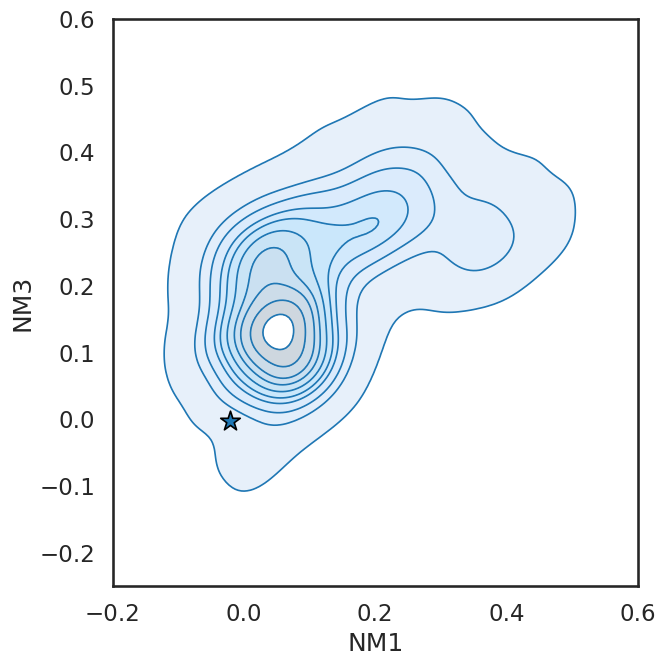

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="talk")


X_LIM = (-0.2, 0.6)
Y_LIM = (-0.20, 0.60) 



COLOR = "#1f77b4"
LABEL = "Donor"

LEVELS = np.linspace(0.010, 0.95, 10)
BW = 1.4
GRIDSIZE = 200
THRESH = 0.0
CUT = 4

STAR_XY = (-0.021,-0.0021)


fig, ax = plt.subplots(figsize=(7, 7))


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=True,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    color=COLOR,
    alpha=0.25,
    ax=ax
)


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=False,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    cut=CUT,
    color=COLOR,
    linewidths=1.2,
    ax=ax
)


ax.scatter(
    *STAR_XY,
    marker="*",
    s=220,
    color=COLOR,
    edgecolor="black",
    linewidth=1.2,
    zorder=10
)


ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.set_xlabel("NM1")
ax.set_ylabel("NM3")


plt.xlim(-0.2, 0.6)
plt.ylim(-0.25,0.6 )

plt.tight_layout()
fig.savefig(
    "NM_projection_substrate_gummi.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


### Contacts

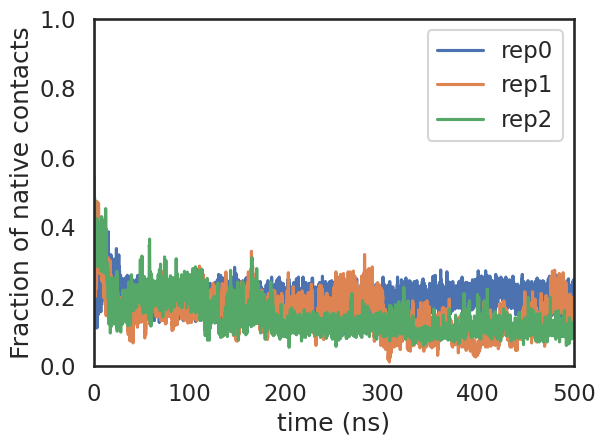

In [31]:
data1 = np.load("native_contacts_Q_rep0_gumi.npy")
data2 = np.load("native_contacts_Q_rep1_gumi.npy")
data3 = np.load("native_contacts_Q_rep2_gumi.npy")

dt = 0.1  # ns
time = np.arange(0, len(data1)*dt, dt)

plt.plot(time, data1, label="rep0")
plt.plot(time, data2, label="rep1")
plt.plot(time, data3, label="rep2")

plt.xlim(0, 500)
plt.ylim(0, 1)


plt.xlabel("time (ns)")
plt.ylabel("Fraction of native contacts")
plt.legend()
plt.tight_layout()
plt.savefig("distance_donor_gumi.png", dpi=600)
plt.show()

# Donor substrate GumH

### Conformations 

In [3]:
data1 = pd.read_csv("gumh_donor_conf_0.csv")
data2 = pd.read_csv("gumh_donor_conf_1.csv")
data3 = pd.read_csv("gumh_donor_conf_2.csv")


replica123 = pd.concat([data1, data2, data3], ignore_index=True)
replica123["dataset"] = "replica1-3"

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

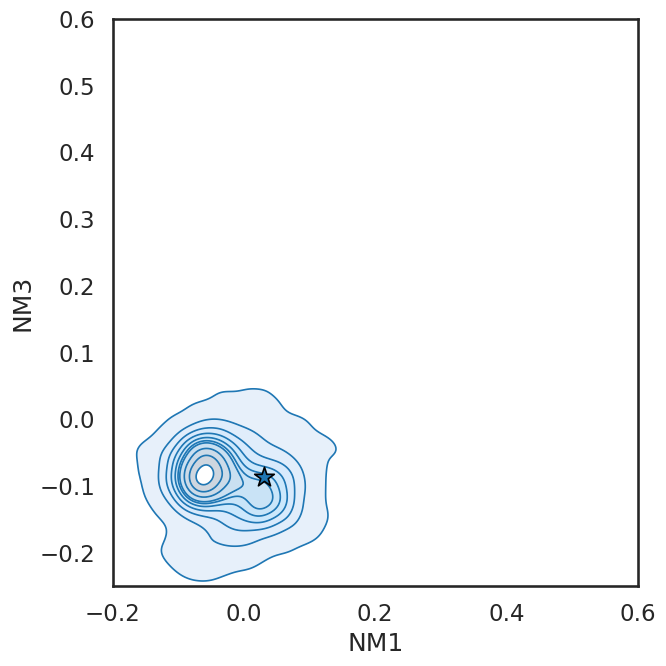

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="talk")


X_LIM = (-0.20, 0.2)
Y_LIM = (-0.25, 0.10) 



COLOR = "#1f77b4"
LABEL = "Donor"

LEVELS = np.linspace(0.010, 0.95, 10)
BW = 1.4
GRIDSIZE = 200
THRESH = 0.0
CUT = 4

STAR_XY = (0.031,-0.087)


fig, ax = plt.subplots(figsize=(7, 7))


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=True,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    color=COLOR,
    alpha=0.25,
    ax=ax
)


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=False,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    cut=CUT,
    color=COLOR,
    linewidths=1.2,
    ax=ax
)


ax.scatter(
    *STAR_XY,
    marker="*",
    s=220,
    color=COLOR,
    edgecolor="black",
    linewidth=1.2,
    zorder=10
)


ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.set_xlabel("NM1")
ax.set_ylabel("NM3")



plt.xlim(-0.2, 0.6)
plt.ylim(-0.25,0.6 )

plt.tight_layout()
fig.savefig(
    "NM_projection_substrate_gummh.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


### Contacts

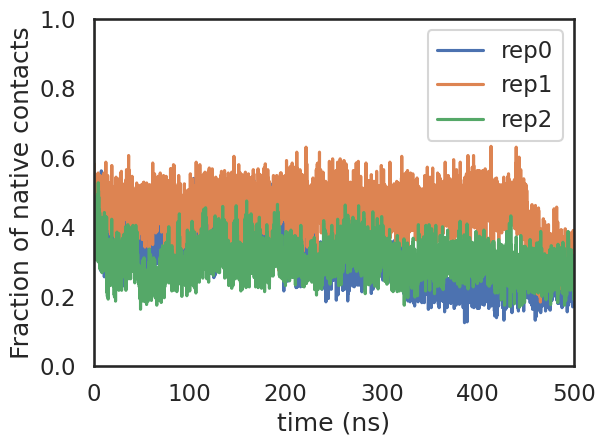

In [32]:
data1 = np.load("native_contacts_Q_rep0_gumh.npy")
data2 = np.load("native_contacts_Q_rep1_gumh.npy")
data3 = np.load("native_contacts_Q_rep2_gumh.npy")

dt = 0.1  # ns
time = np.arange(0, len(data1)*dt, dt)

plt.plot(time, data1, label="rep0")
plt.plot(time, data2, label="rep1")
plt.plot(time, data3, label="rep2")

plt.xlim(0, 500)
plt.ylim(0, 1)


plt.xlabel("time (ns)")
plt.ylabel("Fraction of native contacts")
plt.legend()
plt.tight_layout()
plt.savefig("distance_donor_gumh.png", dpi=600)
plt.show()

# ClustENMD GumI


In [84]:
clust_gumi =pd.read_csv('clustenmd_gumi.csv') 

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

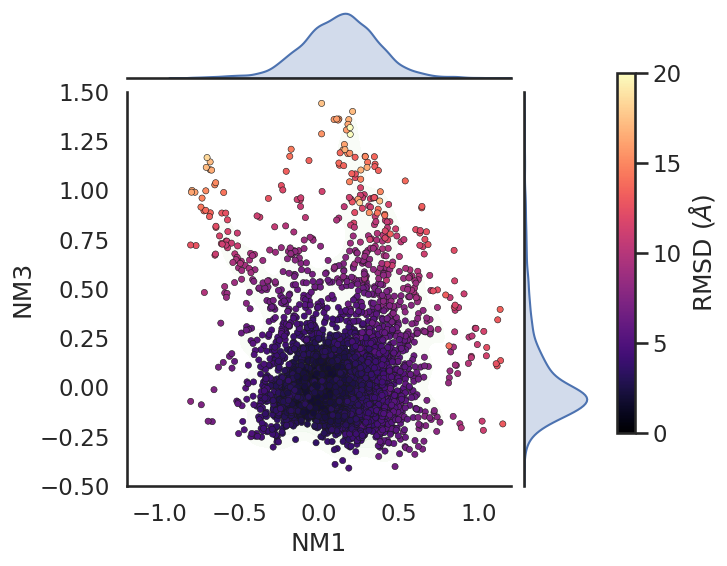

In [85]:

g = sns.jointplot(data=clust_gumi, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)



scatter = g.ax_joint.scatter(clust_gumi['NM1'][::3], clust_gumi['NM3'][::3], c=clust_gumi['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


g.ax_joint.set(xlim=(-1.2,1.2), ylim=(-0.5,1.5))



cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')

scatter.set_clim(vmin=0.0, vmax=20.0)


g.fig.savefig(
    "clustenmd_gumi.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)



In [86]:
clust_gumh =pd.read_csv('clustemd_gumh.csv') 

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

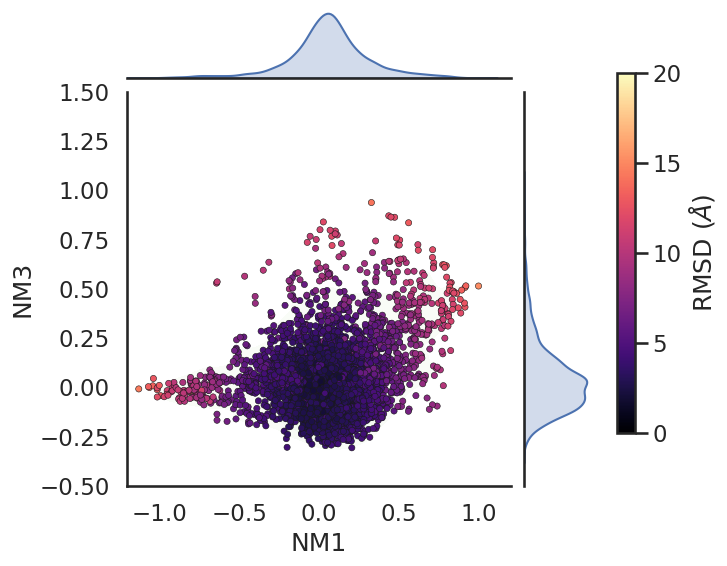

In [87]:

g = sns.jointplot(data=clust_gumh, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)



scatter = g.ax_joint.scatter(clust_gumh['NM1'][::3], clust_gumh['NM3'][::3], c=clust_gumh['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


g.ax_joint.set(xlim=(-1.2,1.2), ylim=(-0.5,1.5))



cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


scatter.set_clim(vmin=0.0, vmax=20.0)

g.fig.savefig(
    "clustenmd_gumh.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)



# Full complex GumH

In [4]:
data1 = pd.read_csv("gumh_full_rep0.csv")
data2 = pd.read_csv("gumh_full_rep1.csv")
data3 = pd.read_csv("gumh_full_rep2.csv")



replica123 = pd.concat([data1, data2, data3], ignore_index=True)
replica123["dataset"] = "replica1-3"

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

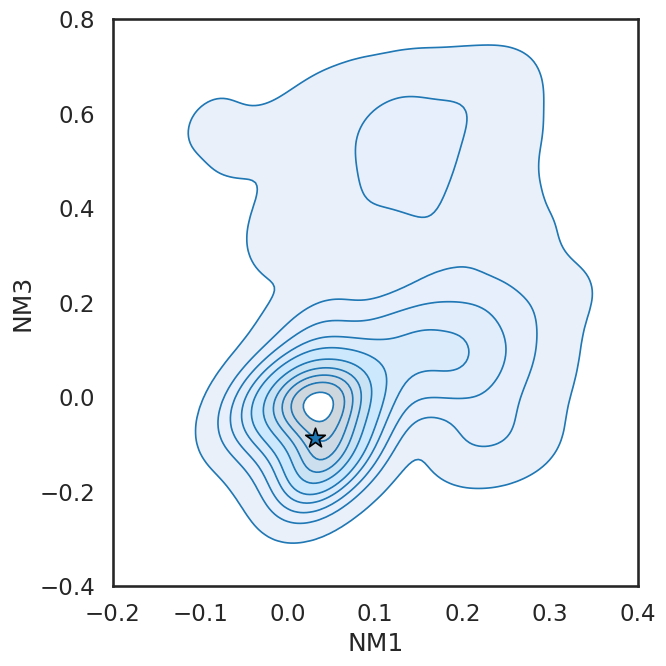

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="talk")


X_LIM = (-0.20, 0.4)
Y_LIM = (-0.4, 0.80) 



COLOR = "#1f77b4"
LABEL = "Donor"

LEVELS = np.linspace(0.010, 0.95, 10)
BW = 1.4
GRIDSIZE = 200
THRESH = 0.0
CUT = 4

STAR_XY = (0.031,-0.087)


fig, ax = plt.subplots(figsize=(7, 7))


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=True,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    color=COLOR,
    alpha=0.25,
    ax=ax
)


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=False,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    cut=CUT,
    color=COLOR,
    linewidths=1.2,
    ax=ax
)


ax.scatter(
    *STAR_XY,
    marker="*",
    s=220,
    color=COLOR,
    edgecolor="black",
    linewidth=1.2,
    zorder=10
)


ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.set_xlabel("NM1")
ax.set_ylabel("NM3")


plt.tight_layout()
fig.savefig(
    "NM_projection_substrate_gummh.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [10]:
data1 = np.load("gumh_full_reactive_dist_rep0.npy")
data2 = np.load("gumh_full_reactive_dist_rep1.npy")
data3 = np.load("gumh_full_reactive_dist_rep2.npy")

data_all = np.concatenate([data1, data2, data3])

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


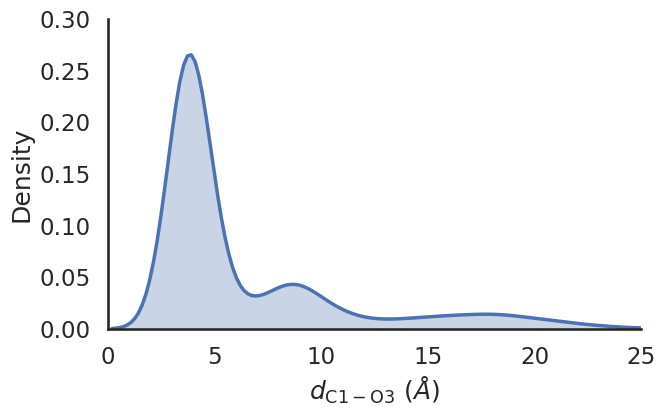

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="talk")

BW = 1.4
fig, ax = plt.subplots(figsize=(7, 4.5))

# filled KDE
sns.kdeplot(
    data_all,
    bw_adjust=BW,
    fill=True,
    alpha=0.30,
    linewidth=0,
    ax=ax
)

# outline KDE
sns.kdeplot(
    data_all,
    bw_adjust=BW,
    linewidth=2.5,
    ax=ax
)


# Axis labels
ax.set_xlabel(r"$d_{\mathrm{C1-O3}}\ (\AA)$")
ax.set_ylabel("Density")

# Axis limits (opzionali, come nel tuo stile)
ax.set_xlim(0, 25)
ax.set_ylim(0, 0.3)

sns.despine()
plt.tight_layout()
plt.savefig(
    "gumh_reactive.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

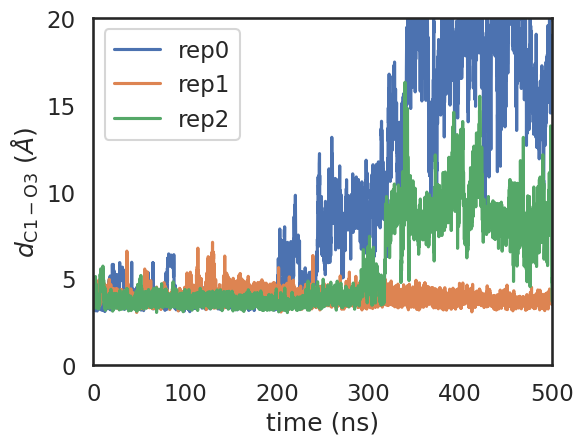

In [34]:
data1 = np.load("gumh_full_reactive_dist_rep0.npy")
data2 = np.load("gumh_full_reactive_dist_rep1.npy")
data3 = np.load("gumh_full_reactive_dist_rep2.npy")

dt = 0.1  # ns
time = np.arange(0, len(data1)*dt, dt)

plt.plot(time, data1, label="rep0")
plt.plot(time, data2, label="rep1")
plt.plot(time, data3, label="rep2")

plt.xlim(0, 500)
plt.ylim(0, 20)


plt.xlabel("time (ns)")
plt.ylabel(r"$d_{\mathrm{C1-O3}}\ (\AA)$")
plt.legend()
plt.tight_layout()
plt.savefig("reactive_distance_replicates_gumh.png", dpi=600)
plt.show()

# Full complex GumI

In [6]:
data1 = pd.read_csv("gumi_full_conf_rep0.csv")
data2 = pd.read_csv("gumi_full_conf_rep1.csv")
data3 = pd.read_csv("gumi_full_conf_rep2.csv")


# unisci le 3 repliche
replica123 = pd.concat([data1, data2, data3], ignore_index=True)
replica123["dataset"] = "replica1-3"

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

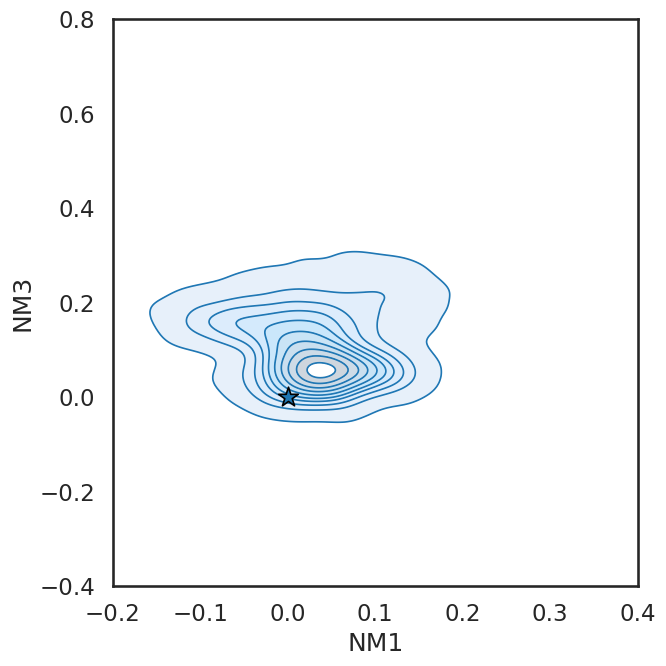

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="talk")


X_LIM = (-0.20, 0.4)
Y_LIM = (-0.4, 0.80) 



COLOR = "#1f77b4"
LABEL = "Donor"

LEVELS = np.linspace(0.010, 0.95, 10)
BW = 1.4
GRIDSIZE = 200
THRESH = 0.0
CUT = 4

STAR_XY = (0.0,0.0)


fig, ax = plt.subplots(figsize=(7, 7))


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=True,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    color=COLOR,
    alpha=0.25,
    ax=ax
)


sns.kdeplot(
    data=replica123,
    x="NM1",
    y="NM3",
    fill=False,
    levels=LEVELS,
    thresh=THRESH,
    bw_adjust=BW,
    gridsize=GRIDSIZE,
    cut=CUT,
    color=COLOR,
    linewidths=1.2,
    ax=ax
)


ax.scatter(
    *STAR_XY,
    marker="*",
    s=220,
    color=COLOR,
    edgecolor="black",
    linewidth=1.2,
    zorder=10
)


ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.set_xlabel("NM1")
ax.set_ylabel("NM3")



plt.tight_layout()
fig.savefig(
    "NM_projection_substrate_gumi.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [13]:
data1 = np.load("gumi_full_reactive_dist_rep0.npy")
data2 = np.load("gumi_full_reactive_dist_rep1.npy")
data3 = np.load("gumi_full_reactive_dist_rep2.npy")

data_all = np.concatenate([data1, data2, data3])

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


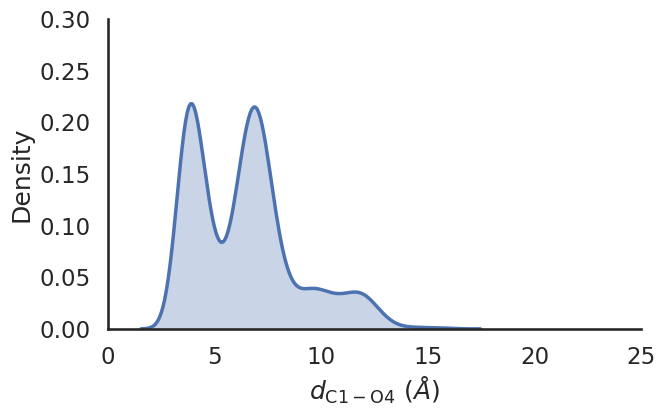

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="talk")

BW = 1.4
fig, ax = plt.subplots(figsize=(7, 4.5))


sns.kdeplot(
    data_all,
    bw_adjust=BW,
    fill=True,
    alpha=0.30,
    linewidth=0,
    ax=ax
)


sns.kdeplot(
    data_all,
    bw_adjust=BW,
    linewidth=2.5,
    ax=ax
)



ax.set_xlabel(r"$d_{\mathrm{C1-O4}}\ (\AA)$")
ax.set_ylabel("Density")


ax.set_xlim(0, 25)
ax.set_ylim(0, 0.3)

sns.despine()
plt.tight_layout()
plt.savefig(
    "gumi_reactive.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

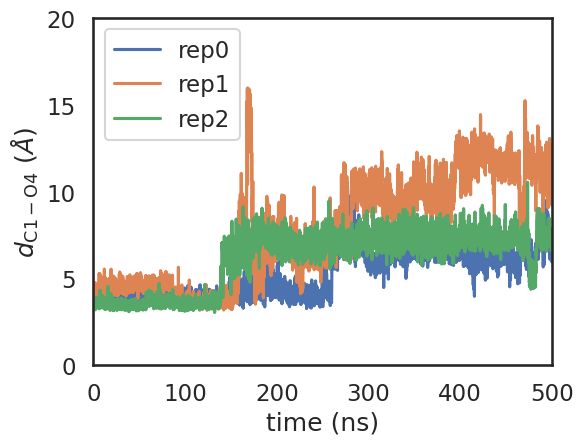

In [35]:
data1 = np.load("gumi_full_reactive_dist_rep0.npy")
data2 = np.load("gumi_full_reactive_dist_rep1.npy")
data3 = np.load("gumi_full_reactive_dist_rep2.npy")

dt = 0.1  # ns
time = np.arange(0, len(data1)*dt, dt)

plt.plot(time, data1, label="rep0")
plt.plot(time, data2, label="rep1")
plt.plot(time, data3, label="rep2")


plt.xlabel("time (ns)")
plt.ylabel(r"$d_{\mathrm{C1-O4}}\ (\AA)$")

plt.xlim(0, 500)
plt.ylim(0, 20)

plt.legend()
plt.tight_layout()
plt.savefig("reactive_distance_replicates_gumi.png", dpi=600)
plt.show()


# Free protein in solution GumI

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib as mpl

In [8]:
data1 = pd.read_csv("closed_rep0_gumi.csv")
data2 = pd.read_csv("closed_rep1_gumi.csv")
data3 = pd.read_csv("closed_rep2_gumi.csv")
data4 = pd.read_csv("free_ensemble_gumi.csv")
data5 = pd.read_csv("free_gumi_ensemble_rep1.csv")
data6 = pd.read_csv("free_gumi_ensemble_rep2.csv")


replica123 = pd.concat([data1, data2, data3], ignore_index=True)
replica123["dataset"] = "replica1-3"


free_ensemble_all = pd.concat([data4, data5, data6], ignore_index=True)
free_ensemble_all["dataset"] = "free_ensemble_rep0-2"

In [9]:
df_all = pd.concat([replica123, free_ensemble_all], ignore_index=True)

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

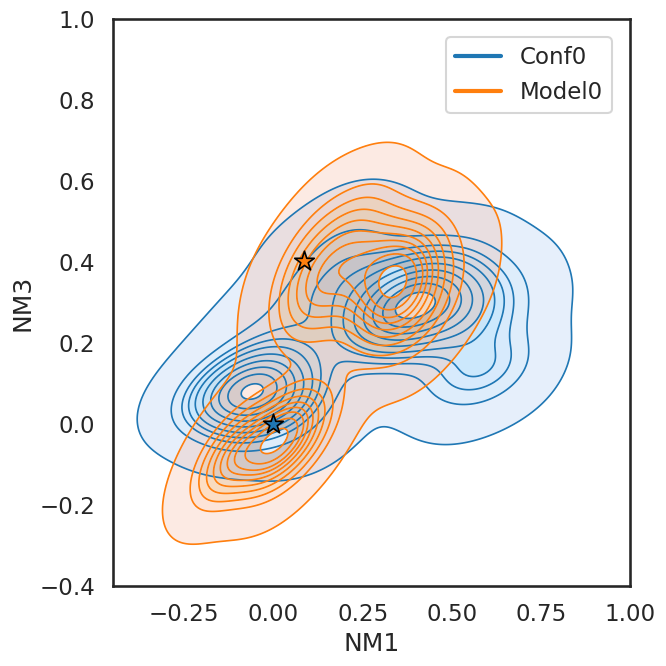

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="talk")


X_LIM = (-0.45, 1.0)
Y_LIM = (-0.40, 1.0)


name_map = {
    "replica1-3": "Conf0",
    "free_ensemble_rep0-2": "Model0",
}

colors = {
    "replica1-3": "#1f77b4",           # blu
    "free_ensemble_rep0-2": "#ff7f0e", # arancione
}


star_coords = {
    "replica1-3": (0.0, 0.0),            # (NM1, NM3)
    "free_ensemble_rep0-2": (0.086, 0.403),
}

levels = np.linspace(0.010, 0.95, 10)

BW = 2.
GRIDSIZE = 400
THRESH = 0.0
CUT = 4

fig, ax = plt.subplots(figsize=(7, 7))

order = ["replica1-3", "free_ensemble_rep0-2"]

for key in order:
    d = df_all[df_all["dataset"] == key]


    sns.kdeplot(
        data=d,
        x="NM1",
        y="NM3",
        fill=True,
        levels=levels,
        thresh=THRESH,
        bw_adjust=BW,
        gridsize=GRIDSIZE,
        color=colors[key],
        alpha=0.25,
        ax=ax
    )


    sns.kdeplot(
        data=d,
        x="NM1",
        y="NM3",
        fill=False,
        levels=levels,
        thresh=THRESH,
        bw_adjust=BW,
        gridsize=GRIDSIZE,
        cut=CUT,
        color=colors[key],
        linewidths=1.2,
        ax=ax
    )


for key in order:
    x, y = star_coords[key]
    ax.scatter(
        x, y,
        marker="*",
        color=colors[key],
        s=220,
        edgecolor="black",
        linewidth=1.2,
        zorder=10
    )


ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)

ax.set_xlabel("NM1")
ax.set_ylabel("NM3")


handles = [
    Line2D([0], [0], color=colors[k], lw=3, label=name_map[k])
    for k in order
]

ax.legend(
    handles=handles,
    loc="upper right",
    borderaxespad=0.8,
    frameon=True
)

plt.tight_layout()
fig.savefig(
    "NM_projection_free.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

blue  = (0.0, 0.35, 0.85)
green = (0.0, 0.65, 0.25)
red   = (0.85, 0.15, 0.15)

def make_colorbar(vmin, vmax, colors, label, outfile):
    cmap = mpl.colors.LinearSegmentedColormap.from_list("custom", colors)

    fig = plt.figure(figsize=(1.4, 4.0))


    ax = fig.add_axes([0.20, 0.08, 0.18, 0.86])

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation="vertical")

    cb.ax.tick_params(labelsize=9, width=0.6, length=3)


    fig.text(0.62, 0.50, label, rotation=90, va="center", ha="left", fontsize=11)

    fig.savefig(outfile, format="svg")
    plt.close(fig)

make_colorbar(0, 5,    [blue, green, red], "RMSF (Å)", "colorbar_RMSF.svg")
make_colorbar(40, 100, [red, green, blue], "pLDDT",    "colorbar_pLDDT.svg")



In [7]:

cmap = mpl.colors.LinearSegmentedColormap.from_list("custom", [red, green, blue])

fig = plt.figure(figsize=(6.0, 0.9))   # più lunga e più bassa

ax = fig.add_axes([0.05, 0.45, 0.90, 0.20])  # meno bianco, barra sottile

norm = mpl.colors.Normalize(vmin=40, vmax=100)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation="horizontal")

cb.set_ticks([40, 60, 80, 100])
cb.ax.tick_params(labelsize=9, width=0.6, length=3)

fig.text(0.50, 0.10, "pLDDT", ha="center", va="center", fontsize=11)

fig.savefig("colorbar_orizzontal_pLDDT.svg", format="svg")
plt.close(fig)
